# Extension of Anand et al. (2024) Reproduction
**Paper:** *Smart Grading of Diabetic Retinopathy: An Intelligent Recommendation-Based Fine-Tuned EfficientNetB0 Framework*  
Frontiers in Artificial Intelligence, vol. 7, 2024.

**Reproduced by:** Eman Ali (23i-2564), Fatima Siddiqa (23i-2543), Mariam Shaiq (23i-3250)  
**Dataset:** APTOS 2019 Blindness Detection + Messidor-2

## Summary of Extensions
- **Section 10** — Ben Graham retinal contrast enhancement (preprocessing novelty over B2)
- **Section 11** — CORAL ordinal loss replacing cross-entropy (architecture novelty)
- **Section 12** — Comparison: B2 vs CORAL + Ben Graham on APTOS 2019
- **Section 13** — Cross-dataset generalization evaluation on Messidor-2 (mandatory)

In [ ]:
from IPython.display import Javascript, display

display(Javascript('''
    function KeepAlive() {
        document.querySelector("#top-toolbar").click();
        setTimeout(KeepAlive, 60000);
    }
    KeepAlive();
'''))

print("Keep-alive started ✓")

<IPython.core.display.Javascript object>

Keep-alive started ✓


## Section 1 — Mount Drive & Unzip Dataset

In [ ]:
import subprocess
subprocess.run(['pip', 'install', '-q', 'gdown'], check=True)
import gdown
print('gdown ready ✓')

gdown ready ✓


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted ✓')

Mounted at /content/drive
Drive mounted ✓


In [ ]:
import os, gdown

EXTRACT_TO = "/content/aptos2019"
os.makedirs(EXTRACT_TO, exist_ok=True)

print('Downloading train_images.zip ...')
gdown.download('https://drive.google.com/uc?id=1yWcJbEKxJHrcL2ztBIhetr6ZOwzl1gkt', '/content/train_images.zip', quiet=False)

print('Downloading test_images.zip ...')
gdown.download('https://drive.google.com/uc?id=1qbXfRz6HiYrff7OlFo1LMJBicvzYHcvg', '/content/test_images.zip', quiet=False)

print('Downloading train.csv ...')
gdown.download('https://drive.google.com/uc?id=1FYPnXLTuCigu95ZXJ-0gT973AYpPZBLN', f'{EXTRACT_TO}/train.csv', quiet=False)

print('Downloading test.csv ...')
gdown.download('https://drive.google.com/uc?id=1nh_2VOJcuklXfFYPSgLuWCIChQCxyRwL', f'{EXTRACT_TO}/test.csv', quiet=False)

print('Unzipping train_images.zip ...')
os.system(f"unzip -q -o /content/train_images.zip -d '{EXTRACT_TO}'")
print('Train done.')

print('Unzipping test_images.zip ...')
os.system(f"unzip -q -o /content/test_images.zip -d '{EXTRACT_TO}'")
print('Test done.')

print('\nContents:')
print(os.listdir(EXTRACT_TO))
print('\nAll done.')

Downloading...
From (original): https://drive.google.com/uc?id=1yWcJbEKxJHrcL2ztBIhetr6ZOwzl1gkt
From (redirected): https://drive.google.com/uc?id=1yWcJbEKxJHrcL2ztBIhetr6ZOwzl1gkt&confirm=t&uuid=a6ab98f8-fa23-40c5-ab30-364d7be71080
To: /content/train_images.zip
100%|██████████| 8.60G/8.60G [01:36<00:00, 88.8MB/s]


Downloading...
From (original): https://drive.google.com/uc?id=1qbXfRz6HiYrff7OlFo1LMJBicvzYHcvg
From (redirected): https://drive.google.com/uc?id=1qbXfRz6HiYrff7OlFo1LMJBicvzYHcvg&confirm=t&uuid=7ebca840-8b81-4001-a374-c3d18b2a6429
To: /content/test_images.zip
100%|██████████| 1.61G/1.61G [00:15<00:00, 106MB/s] 


Downloading...
From: https://drive.google.com/uc?id=1FYPnXLTuCigu95ZXJ-0gT973AYpPZBLN
To: /content/aptos2019/train.csv
100%|██████████| 54.9k/54.9k [00:00<00:00, 71.7MB/s]


Downloading...
From: https://drive.google.com/uc?id=1nh_2VOJcuklXfFYPSgLuWCIChQCxyRwL
To: /content/aptos2019/test.csv
100%|██████████| 25.1k/25.1k [00:00<00:00, 51.6MB/s]


Unzipping train_images.zip ...
Train done.
Unzipping test_images.zip ...
Test done.

Contents:
['5ea81ad2e8f2.png', '721214151233.png', 'add1d681d712.png', '878e356c8fc9.png', '2f4e81787d9b.png', '87295c5fa1cc.png', 'b1f69a5b75d4.png', '2c739d725e5e.png', 'bf7b4eae7ad0.png', '8fc74bd50fcb.png', '44e0d56e9d42.png', '4ccee4db09b6.png', '286e9981dd9b.png', '6298468d7d75.png', 'ae57c8630249.png', '7a7f72b1c5ce.png', '99ecdb41d5e7.png', 'cb0cc98d7e35.png', '3218a6d8eb2c.png', '38e0e28d35d3.png', '2923971566fe.png', '524f240e0c90.png', 'e0d229db881a.png', '7e4019ac7f5a.png', '14c3b41d289c.png', '683023cda6a5.png', '4fa26d065ad3.png', 'a95858e052d6.png', 'a45d77edf8d9.png', 'a8e88d4891c4.png', '6e19f08344ed.png', '89d9c071a56f.png', '70d657f8f503.png', 'de202d6ca406.png', 'fee5bd042c3b.png', 'd10ef306996b.png', 'c8905b8d5cf1.png', 'c9725a732b15.png', '2047c76a05da.png', 'aad0c0ee9268.png', '94ef1d14597f.png', '2209daf71aab.png', '63363410389a.png', '9bf060db8376.png', '6c96703bc565.png', 'e82

In [ ]:
import os

contents = os.listdir(EXTRACT_TO)
print("Extracted contents:", contents)

for candidate in ["train_images", "train"]:
    full = os.path.join(EXTRACT_TO, candidate)
    if os.path.isdir(full):
        DETECTED_IMG_DIR = full
        print(f"\nDetected train image folder: {DETECTED_IMG_DIR}")
        print(f"Number of images: {len(os.listdir(DETECTED_IMG_DIR))}")
        break
else:
    print("\nWARNING: Could not auto-detect image folder.")
    print("Please manually set IMG_DIR in Section 3 Config.")
    DETECTED_IMG_DIR = EXTRACT_TO

!cp "{TRAIN_CSV}" "{EXTRACT_TO}/train.csv"
!cp "{TEST_CSV}"  "{EXTRACT_TO}/test.csv"
print(f"\nCSV files copied to {EXTRACT_TO}")

Extracted contents: ['5ea81ad2e8f2.png', '721214151233.png', 'add1d681d712.png', '878e356c8fc9.png', '2f4e81787d9b.png', '87295c5fa1cc.png', 'b1f69a5b75d4.png', '2c739d725e5e.png', 'bf7b4eae7ad0.png', '8fc74bd50fcb.png', '44e0d56e9d42.png', '4ccee4db09b6.png', '286e9981dd9b.png', '6298468d7d75.png', 'ae57c8630249.png', '7a7f72b1c5ce.png', '99ecdb41d5e7.png', 'cb0cc98d7e35.png', '3218a6d8eb2c.png', '38e0e28d35d3.png', '2923971566fe.png', '524f240e0c90.png', 'e0d229db881a.png', '7e4019ac7f5a.png', '14c3b41d289c.png', '683023cda6a5.png', '4fa26d065ad3.png', 'a95858e052d6.png', 'a45d77edf8d9.png', 'a8e88d4891c4.png', '6e19f08344ed.png', '89d9c071a56f.png', '70d657f8f503.png', 'de202d6ca406.png', 'fee5bd042c3b.png', 'd10ef306996b.png', 'c8905b8d5cf1.png', 'c9725a732b15.png', '2047c76a05da.png', 'aad0c0ee9268.png', '94ef1d14597f.png', '2209daf71aab.png', '63363410389a.png', '9bf060db8376.png', '6c96703bc565.png', 'e82232a3c28b.png', '842d697884f6.png', '40140a925c43.png', '643ff5d1f90f.png',

## Section 2 — Install Libraries & Imports

In [ ]:
!pip install -q torch torchvision scikit-learn seaborn matplotlib pandas pillow

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

#  Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

print("All libraries imported successfully.")

All libraries imported successfully.


## Section 3 — Configuration

In [ ]:
class Config:
    DATA_DIR   = "/content/aptos2019"
    CSV_PATH   = os.path.join(DATA_DIR, "train.csv")
    IMG_DIR    = "/content/aptos2019"
    OUTPUT_DIR = "/content/drive/MyDrive/aptos_outputs"

    NUM_CLASSES  = 5
    IMG_SIZE     = 224
    BATCH_SIZE   = 16
    EPOCHS       = 15
    LR           = 1e-3
    LR_FINETUNE  = 1e-5
    DROPOUT      = 0.4
    WEIGHT_DECAY = 1e-4
    PATIENCE     = 5
    VAL_SPLIT    = 0.2

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    GRADE_NAMES = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]

os.makedirs(Config.OUTPUT_DIR, exist_ok=True)
print(f"Device     : {Config.DEVICE}")
print(f"CSV path   : {Config.CSV_PATH}")
print(f"Image dir  : {Config.IMG_DIR}")
print(f"Output dir : {Config.OUTPUT_DIR}")

Device     : cuda
CSV path   : /content/aptos2019/train.csv
Image dir  : /content/aptos2019
Output dir : /content/drive/MyDrive/aptos_outputs


## Section 4 — Exploratory Data Analysis

In [ ]:
df_full = pd.read_csv(Config.CSV_PATH)
print("Columns:", df_full.columns.tolist())
print(df_full.head())

print("\n── APTOS 2019 Dataset Summary ───────────────────────────────────")
print(f"  Total images : {len(df_full)}")
print(f"  Train split  : {int(len(df_full) * 0.8)}")
print(f"  Val split    : {int(len(df_full) * 0.2)}")
print("\n  Grade | Name            | Count | %")
print("  " + "-" * 45)
for g in range(Config.NUM_CLASSES):
    n   = (df_full["diagnosis"] == g).sum()
    pct = n / len(df_full) * 100
    print(f"  {g}     | {Config.GRADE_NAMES[g]:<15} | {n:>5} | {pct:.1f}%")

Columns: ['id_code', 'diagnosis']
        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0

── APTOS 2019 Dataset Summary ───────────────────────────────────
  Total images : 3662
  Train split  : 2929
  Val split    : 732

  Grade | Name            | Count | %
  ---------------------------------------------
  0     | No DR           |  1805 | 49.3%
  1     | Mild            |   370 | 10.1%
  2     | Moderate        |   999 | 27.3%
  3     | Severe          |   193 | 5.3%
  4     | Proliferative   |   295 | 8.1%


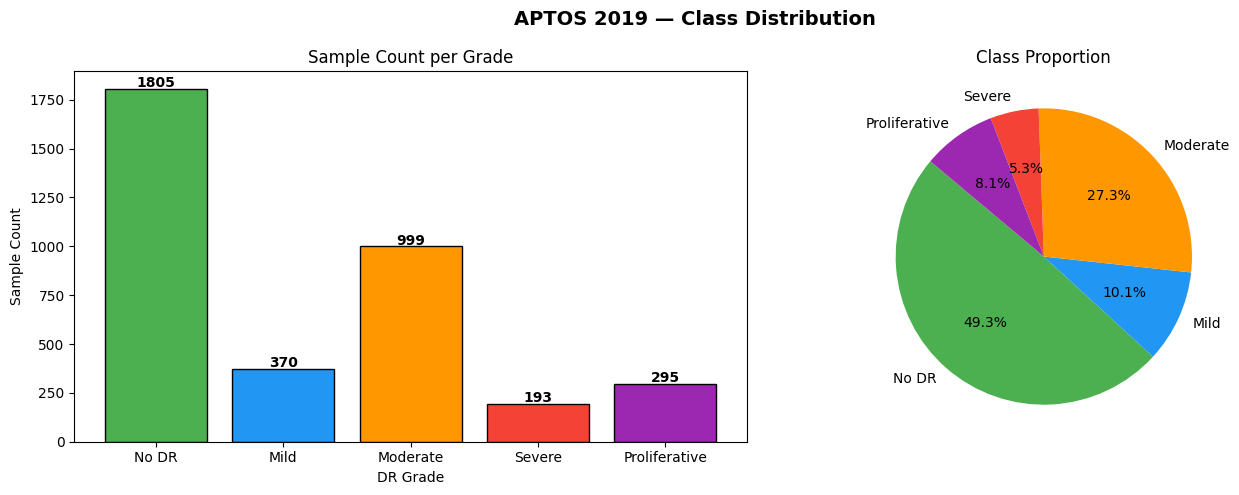

Saved → /content/drive/MyDrive/aptos_outputs/class_distribution.png


In [ ]:
counts = df_full["diagnosis"].value_counts().sort_index()
colors = ["#4CAF50", "#2196F3", "#FF9800", "#F44336", "#9C27B0"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("APTOS 2019 — Class Distribution", fontsize=14, fontweight="bold")

axes[0].bar(Config.GRADE_NAMES, counts.values, color=colors, edgecolor="black")
axes[0].set_xlabel("DR Grade")
axes[0].set_ylabel("Sample Count")
axes[0].set_title("Sample Count per Grade")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

axes[1].pie(counts.values, labels=Config.GRADE_NAMES, colors=colors,
            autopct="%1.1f%%", startangle=140)
axes[1].set_title("Class Proportion")

plt.tight_layout()
path = os.path.join(Config.OUTPUT_DIR, "class_distribution.png")
plt.savefig(path, dpi=150)
plt.show()
print(f"Saved → {path}")

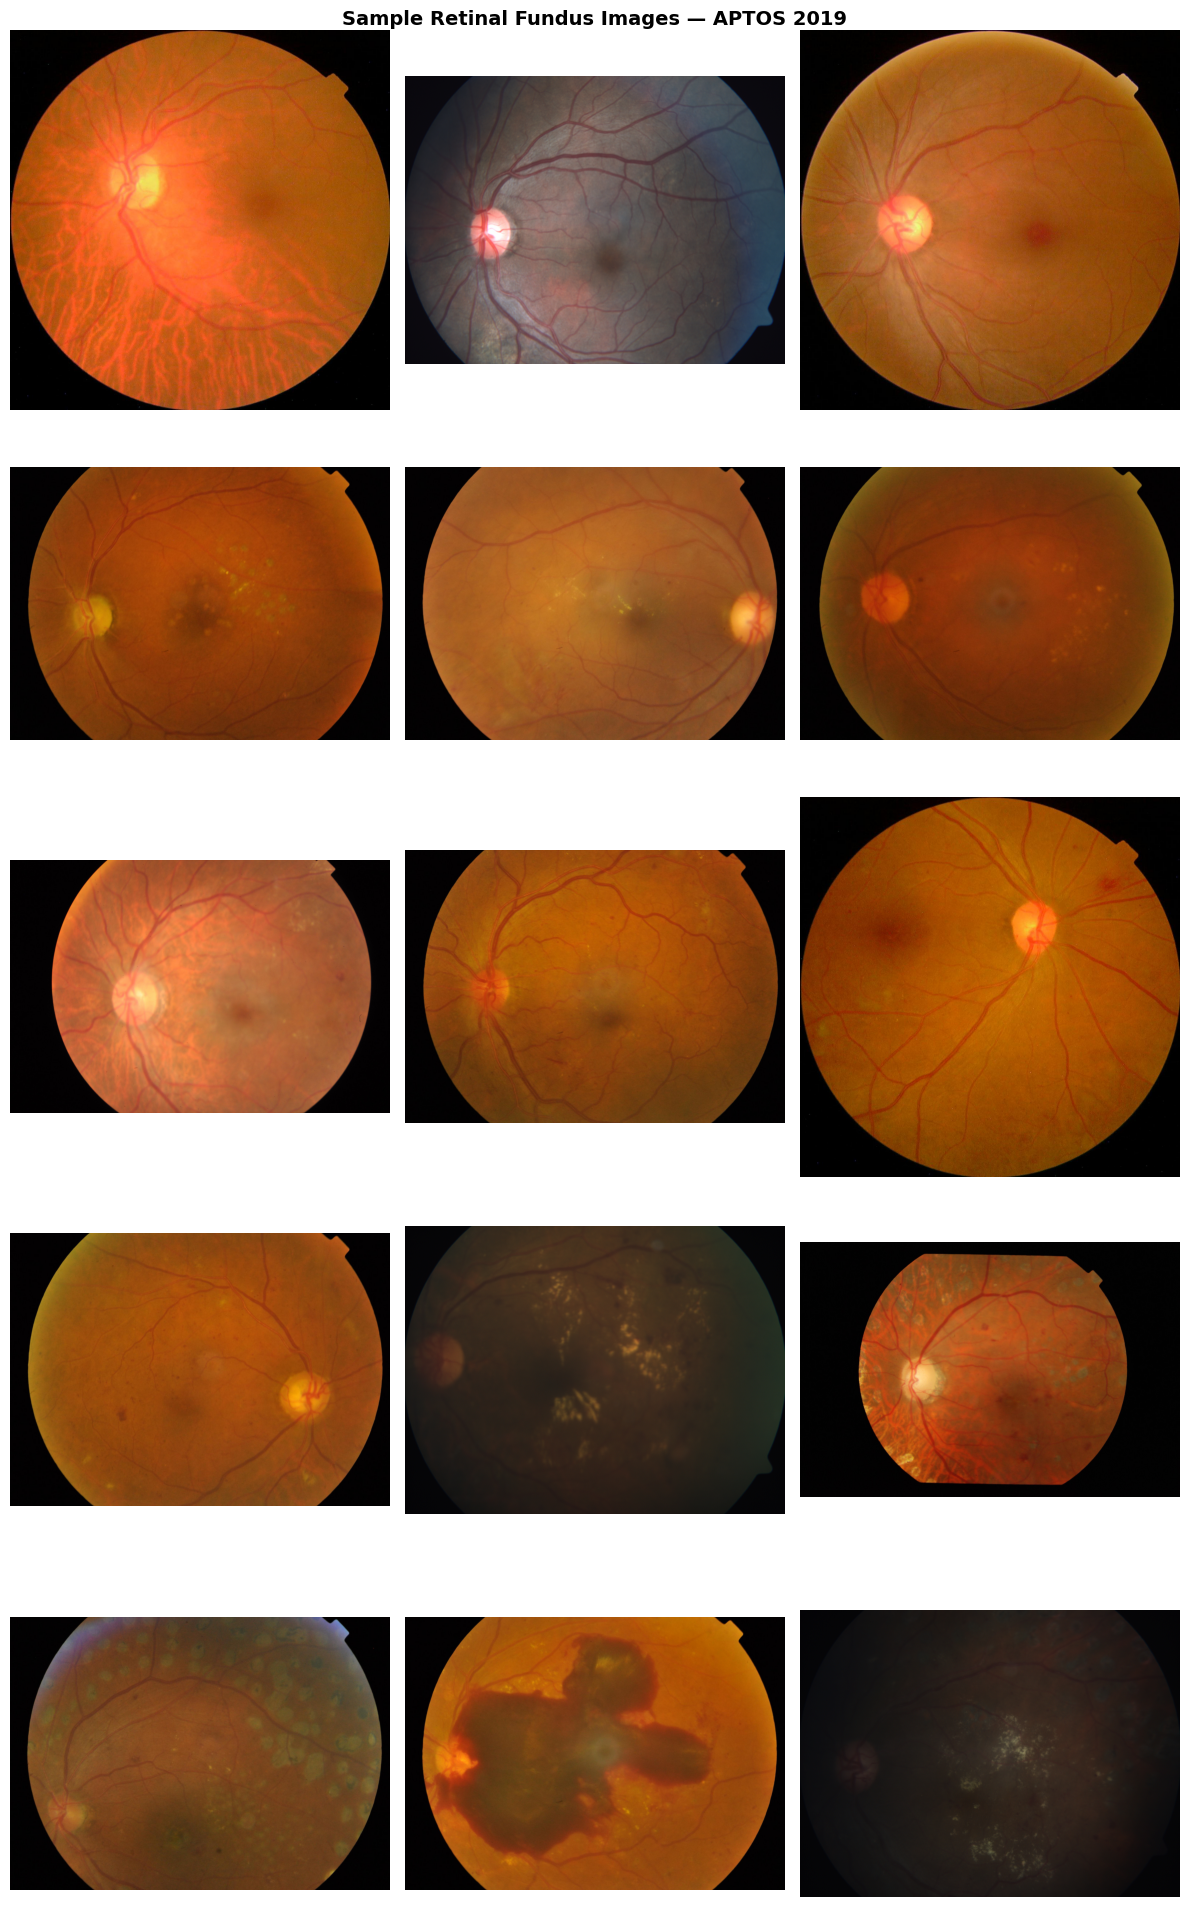

Saved → /content/drive/MyDrive/aptos_outputs/sample_grid.png


In [ ]:
N_PER_CLASS = 3
fig = plt.figure(figsize=(N_PER_CLASS * 4, Config.NUM_CLASSES * 4))
gs  = gridspec.GridSpec(Config.NUM_CLASSES, N_PER_CLASS, figure=fig)
fig.suptitle("Sample Retinal Fundus Images — APTOS 2019", fontsize=14, fontweight="bold")

for grade in range(Config.NUM_CLASSES):
    samples = df_full[df_full["diagnosis"] == grade].sample(N_PER_CLASS, random_state=42)
    for col, (_, row) in enumerate(samples.iterrows()):
        img_path = os.path.join(Config.IMG_DIR, row["id_code"] + ".png")
        try:
            img = Image.open(img_path).convert("RGB")
            ax  = fig.add_subplot(gs[grade, col])
            ax.imshow(img)
            ax.axis("off")
            if col == 0:
                ax.set_ylabel(f"Grade {grade}\n{Config.GRADE_NAMES[grade]}",
                              fontsize=10, rotation=0, labelpad=60, va="center")
        except FileNotFoundError:
            print(f"  Image not found: {img_path}")

plt.tight_layout()
path = os.path.join(Config.OUTPUT_DIR, "sample_grid.png")
plt.savefig(path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved → {path}")

## Section 5 — Dataset & DataLoaders

In [ ]:
class APTOSDataset(Dataset):
    """APTOS 2019 retinal fundus dataset."""
    def __init__(self, df, img_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["id_code"] + ".png")
        image    = Image.open(img_path).convert("RGB")
        label    = int(row["diagnosis"])
        if self.transform:
            image = self.transform(image)
        return image, label


def get_transforms():
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    train_tf = transforms.Compose([
        transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(180),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    val_tf = transforms.Compose([
        transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    return train_tf, val_tf


def build_dataloaders(csv_path, img_dir):
    df = pd.read_csv(csv_path)
    print(f"Total samples: {len(df)}")
    print("Class distribution:\n", df["diagnosis"].value_counts().sort_index())

    train_df, val_df = train_test_split(
        df, test_size=Config.VAL_SPLIT, random_state=SEED,
        stratify=df["diagnosis"]
    )
    print(f"\nTrain: {len(train_df)} | Val: {len(val_df)}")

    train_tf, val_tf = get_transforms()
    train_ds = APTOSDataset(train_df, img_dir, train_tf)
    val_ds   = APTOSDataset(val_df,   img_dir, val_tf)

    # WeightedRandomSampler to handle class imbalance
    class_counts   = train_df["diagnosis"].value_counts().sort_index().values
    class_weights  = 1.0 / class_counts
    sample_weights = [class_weights[label] for label in train_df["diagnosis"]]
    sampler = torch.utils.data.WeightedRandomSampler(
        weights=sample_weights, num_samples=len(sample_weights), replacement=True
    )

    train_loader = DataLoader(train_ds, batch_size=Config.BATCH_SIZE,
                              sampler=sampler, num_workers=0, pin_memory=False)
    val_loader   = DataLoader(val_ds,   batch_size=Config.BATCH_SIZE,
                              shuffle=False, num_workers=0, pin_memory=False)
    return train_loader, val_loader


train_loader, val_loader = build_dataloaders(Config.CSV_PATH, Config.IMG_DIR)
print("\nDataLoaders ready.")

Total samples: 3662
Class distribution:
 diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64

Train: 2929 | Val: 733

DataLoaders ready.


In [ ]:
def build_model(freeze_backbone=True):
    """
    EfficientNet-B0 pretrained on ImageNet.
    Custom head: Dropout → FC(1280→512) → ReLU → Dropout → FC(512→5)
    Mirrors Anand et al. (2024) architecture.
    """
    model = models.efficientnet_b0(
        weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
    )
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=Config.DROPOUT),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(512, Config.NUM_CLASSES),
    )
    return model.to(Config.DEVICE)


def unfreeze_backbone(model, lr_finetune):
    for param in model.parameters():
        param.requires_grad = True
    return optim.AdamW(
        model.parameters(), lr=lr_finetune, weight_decay=Config.WEIGHT_DECAY
    )


model = build_model(freeze_backbone=True)
print("Model built. Classifier head:")
print(model.classifier)


import gc
gc.collect()
torch.cuda.empty_cache()
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
print(f"\nGPU memory allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"GPU memory reserved : {torch.cuda.memory_reserved()  / 1e9:.2f} GB")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 163MB/s]


Model built. Classifier head:
Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=1280, out_features=512, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=512, out_features=5, bias=True)
)

GPU memory allocated: 0.02 GB
GPU memory reserved : 0.04 GB


## Section 7 — Training

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(Config.DEVICE), labels.to(Config.DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)

        del images, labels, outputs, loss, preds
        torch.cuda.empty_cache()

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for images, labels in loader:
        images, labels = images.to(Config.DEVICE), labels.to(Config.DEVICE)
        outputs = model(images)
        loss    = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        probs  = torch.softmax(outputs, dim=1)
        preds  = probs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += images.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

        del images, labels, outputs, loss, probs, preds
        torch.cuda.empty_cache()

    return (total_loss / total, correct / total,
            np.array(all_preds), np.array(all_labels), np.array(all_probs))

print("Training helpers defined.")

Training helpers defined.


In [ ]:
# ── Stage 1: Head-only training (5 epochs) ───────────────────────────────────
criterion    = nn.CrossEntropyLoss()
optimizer_s1 = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=Config.LR, weight_decay=Config.WEIGHT_DECAY
)
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

print("── Stage 1: Head-only training ──────────────────────────────────")
for epoch in range(5):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer_s1)
    vl_loss, vl_acc, _, _, _ = evaluate(model, val_loader, criterion)
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)
    print(f"  Epoch {epoch+1:02d}/05 | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}")

── Stage 1: Head-only training ──────────────────────────────────
  Epoch 01/05 | Train Loss: 1.1815 Acc: 0.4988 | Val Loss: 0.8900 Acc: 0.6780
  Epoch 02/05 | Train Loss: 1.1231 Acc: 0.5230 | Val Loss: 0.7900 Acc: 0.7040
  Epoch 03/05 | Train Loss: 1.0853 Acc: 0.5411 | Val Loss: 0.8679 Acc: 0.6153
  Epoch 04/05 | Train Loss: 1.0588 Acc: 0.5596 | Val Loss: 0.7834 Acc: 0.6562
  Epoch 05/05 | Train Loss: 1.0295 Acc: 0.5859 | Val Loss: 0.7518 Acc: 0.6889


In [ ]:
# Stage 2: Full fine-tuning
optimizer_s2 = unfreeze_backbone(model, Config.LR_FINETUNE)
scheduler    = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_s2, T_max=Config.EPOCHS
)

best_val_acc = 0.0
patience_ctr = 0
best_ckpt    = os.path.join(Config.OUTPUT_DIR, "best_model.pth")
latest_ckpt  = os.path.join(Config.OUTPUT_DIR, "latest_model.pth")

start_epoch = 0
if os.path.exists(latest_ckpt):
    print("Resuming from checkpoint...")
    ckpt = torch.load(latest_ckpt, map_location=Config.DEVICE)
    model.load_state_dict(ckpt["model_state"])
    optimizer_s2.load_state_dict(ckpt["optimizer_state"])
    start_epoch  = ckpt["epoch"] + 1
    best_val_acc = ckpt["best_val_acc"]
    history      = ckpt["history"]
    print(f"  Resumed from epoch {start_epoch}, best val acc: {best_val_acc:.4f}")
else:
    print("Starting fresh.")

print("Stage 2: Full fine-tuning")
for epoch in range(start_epoch, Config.EPOCHS):  # ← start_epoch instead of 0
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer_s2)
    vl_loss, vl_acc, vl_preds, vl_labels, vl_probs = evaluate(
        model, val_loader, criterion
    )
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    print(f"  Epoch {epoch+1:02d}/{Config.EPOCHS} | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}")

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        patience_ctr = 0
        torch.save(model.state_dict(), best_ckpt)
        print(f"     Saved best model (val acc: {best_val_acc:.4f})")
    else:
        patience_ctr += 1
        if patience_ctr >= Config.PATIENCE:
            print(f"  Early stopping at epoch {epoch+1}.")
            break

    torch.save({
        "epoch":           epoch,
        "model_state":     model.state_dict(),
        "optimizer_state": optimizer_s2.state_dict(),
        "best_val_acc":    best_val_acc,
        "history":         history,
    }, latest_ckpt)

print("\nTraining complete.")

Resuming from checkpoint...
  Resumed from epoch 5, best val acc: 0.7176
Stage 2: Full fine-tuning
  Epoch 06/15 | Train Loss: 0.8719 Acc: 0.6415 | Val Loss: 0.6809 Acc: 0.7217
     Saved best model (val acc: 0.7217)


KeyboardInterrupt: 

## Section 8 — Evaluation & Results

In [ ]:
def compute_metrics(y_true, y_pred, y_prob):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="macro", zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
    except Exception:
        auc = float("nan")
    return {"accuracy": acc, "precision": prec, "recall": rec,
            "f1": f1, "auc": auc}


model.load_state_dict(torch.load(best_ckpt, map_location=Config.DEVICE))
_, _, vl_preds, vl_labels, vl_probs = evaluate(model, val_loader, criterion)
metrics = compute_metrics(vl_labels, vl_preds, vl_probs)

print("── Final Evaluation (best checkpoint) ───────────────────────────")
print(f"  Accuracy  : {metrics['accuracy']:.4f}")
print(f"  Precision : {metrics['precision']:.4f}")
print(f"  Recall    : {metrics['recall']:.4f}")
print(f"  F1-Score  : {metrics['f1']:.4f}")
print(f"  AUC       : {metrics['auc']:.4f}")
print("\nClassification Report:")
print(classification_report(vl_labels, vl_preds, target_names=Config.GRADE_NAMES))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"],   label="Val Loss")
axes[0].axvline(x=4, color="gray", linestyle="--", alpha=0.5, label="Stage 1→2")
axes[0].set_title("Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train Accuracy")
axes[1].plot(history["val_acc"],   label="Val Accuracy")
axes[1].axvline(x=4, color="gray", linestyle="--", alpha=0.5, label="Stage 1→2")
axes[1].set_title("Accuracy Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
path = os.path.join(Config.OUTPUT_DIR, "training_curves.png")
plt.savefig(path, dpi=150)
plt.show()
print(f"Saved → {path}")

In [ ]:
# Confusion matrix
cm = confusion_matrix(vl_labels, vl_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=Config.GRADE_NAMES,
            yticklabels=Config.GRADE_NAMES)
plt.title("Confusion Matrix — EfficientNet-B0 on APTOS 2019")
plt.ylabel("True Grade")
plt.xlabel("Predicted Grade")
plt.tight_layout()
path = os.path.join(Config.OUTPUT_DIR, "confusion_matrix.png")
plt.savefig(path, dpi=150)
plt.show()
print(f"Saved → {path}")

In [ ]:
# Results comparison table
rows = {
    "Metric":            ["Accuracy", "Precision (Macro)", "Recall (Macro)",
                          "F1-Score (Macro)", "AUC (Macro OvR)"],
    "Paper Result":      [0.91,       "N/R",               "N/R",
                          "N/R",      0.9949],
    "Reproduced Result": [
        round(metrics["accuracy"],  4),
        round(metrics["precision"], 4),
        round(metrics["recall"],    4),
        round(metrics["f1"],        4),
        round(metrics["auc"],       4),
    ],
}
results_df = pd.DataFrame(rows)
path = os.path.join(Config.OUTPUT_DIR, "results_comparison.csv")
results_df.to_csv(path, index=False)
print(f"Saved → {path}\n")
print(results_df.to_string(index=False))

## Section 9 — GradCAM Explainability

In [ ]:
class GradCAM:
    """
    Selvaraju et al. (2017) — gradient-based class activation maps.
    Hooks into the last convolutional block of EfficientNet-B0.
    """
    def __init__(self, model):
        self.model       = model
        self.gradients   = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        target_layer = self.model.features[-1]

        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        target_layer.register_forward_hook(forward_hook)
        target_layer.register_full_backward_hook(backward_hook)

    def generate(self, image_tensor, class_idx=None):
        self.model.eval()
        image_tensor = image_tensor.unsqueeze(0).to(Config.DEVICE)
        image_tensor.requires_grad_(True)
        output = self.model(image_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        self.model.zero_grad()
        output[0, class_idx].backward()
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam     = (weights * self.activations).sum(dim=1).squeeze()
        cam     = F.relu(cam)
        cam     = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam.cpu().numpy(), class_idx


def overlay_cam(original_img, cam, alpha=0.5):
    h, w = np.array(original_img).shape[:2]
    cam_resized = np.array(
        Image.fromarray((cam * 255).astype(np.uint8)).resize((w, h))
    ) / 255.0
    colormap = plt.cm.jet(cam_resized)[..., :3]
    original = np.array(original_img) / 255.0
    blended  = alpha * colormap + (1 - alpha) * original
    return np.clip(blended, 0, 1)


print("GradCAM class defined.")

In [ ]:
val_tf_gradcam = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

model.load_state_dict(torch.load(best_ckpt, map_location=Config.DEVICE))
gradcam = GradCAM(model)

sample_paths, sample_labels = [], []
df_csv = pd.read_csv(Config.CSV_PATH)
for grade in range(Config.NUM_CLASSES):
    row = df_csv[df_csv["diagnosis"] == grade].sample(1, random_state=SEED).iloc[0]
    sample_paths.append(os.path.join(Config.IMG_DIR, row["id_code"] + ".png"))
    sample_labels.append(grade)

n   = Config.NUM_CLASSES
fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
fig.suptitle("GradCAM Explainability — EfficientNet-B0 on APTOS 2019",
             fontsize=14, fontweight="bold")

for i, (img_path, true_label) in enumerate(zip(sample_paths, sample_labels)):
    original = Image.open(img_path).convert("RGB").resize(
        (Config.IMG_SIZE, Config.IMG_SIZE)
    )
    tensor        = val_tf_gradcam(original)
    cam, pred_cls = gradcam.generate(tensor)
    overlay       = overlay_cam(original, cam)

    axes[i, 0].imshow(original)
    axes[i, 0].set_title(f"Original | True: {Config.GRADE_NAMES[true_label]}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(cam, cmap="jet")
    axes[i, 1].set_title("GradCAM Heatmap")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(overlay)
    axes[i, 2].set_title(f"Overlay | Pred: {Config.GRADE_NAMES[pred_cls]}")
    axes[i, 2].axis("off")

plt.tight_layout()
path = os.path.join(Config.OUTPUT_DIR, "gradcam_visualisations.png")
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved GradCAM visualisations → {path}")

## Section 10 — Ben Graham Preprocessing (A3 Extension)

In [ ]:
import cv2

def ben_graham_enhance(pil_img, sigma=30):
    img = np.array(pil_img.convert("RGB"))
    blurred = cv2.GaussianBlur(img, (0, 0), sigma)
    enhanced = cv2.addWeighted(img, 4, blurred, -4, 128)
    enhanced = np.clip(enhanced, 0, 255).astype(np.uint8)
    return Image.fromarray(enhanced)

class APTOSDatasetBG(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["id_code"] + ".png")
        image = Image.open(img_path).convert("RGB")
        image = ben_graham_enhance(image)
        label = int(row["diagnosis"])
        if self.transform:
            image = self.transform(image)
        return image, label

df_full = pd.read_csv(Config.CSV_PATH)
df_train, df_val = train_test_split(df_full, test_size=Config.VAL_SPLIT,
                                     stratify=df_full["diagnosis"], random_state=42)

train_tf, val_tf = get_transforms()
train_loader_bg = DataLoader(APTOSDatasetBG(df_train, Config.IMG_DIR, train_tf),
                              batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=2)
val_loader_bg   = DataLoader(APTOSDatasetBG(df_val,   Config.IMG_DIR, val_tf),
                              batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=2)

print("Ben Graham DataLoaders ready.")

Ben Graham DataLoaders ready.


## Section 11 — CORAL Model & Training

In [ ]:
import torch.nn as nn
from torchvision import models
class CORALHead(nn.Module):
    def __init__(self, in_features, num_classes=5):
        super().__init__()
        self.fc   = nn.Linear(in_features, 1, bias=False)
        self.bias = nn.Parameter(torch.zeros(num_classes - 1))

    def forward(self, x):
        return torch.sigmoid(self.fc(x) + self.bias)

def coral_loss(outputs, targets, num_classes=5):
    sets   = [targets > i for i in range(num_classes - 1)]
    labels = torch.stack(sets, dim=1).float()
    return nn.functional.binary_cross_entropy(outputs, labels)

def coral_predict(outputs):
    return (outputs > 0.5).sum(dim=1)


def build_coral_model(freeze_backbone=True):
    m = models.efficientnet_b0(
        weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
    )
    if freeze_backbone:
        for param in m.parameters():
            param.requires_grad = False
    in_features = m.classifier[1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(p=Config.DROPOUT),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        CORALHead(512)
    )
    return m.to(Config.DEVICE)

coral_model = build_coral_model(freeze_backbone=True)
print("CORAL model built.")
print(coral_model.classifier)

def train_coral_epoch(model, loader, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(Config.DEVICE), labels.to(Config.DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = coral_loss(outputs, labels)
        loss.backward()
        optimizer.step()
        preds       = coral_predict(outputs)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)
        total_loss += loss.item() * images.size(0)
        del images, labels, outputs, loss, preds
        torch.cuda.empty_cache()
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate_coral(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(Config.DEVICE), labels.to(Config.DEVICE)
        outputs = model(images)
        loss    = coral_loss(outputs, labels)
        preds   = coral_predict(outputs)
        total_loss  += loss.item() * images.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        del images, labels, outputs, loss, preds
        torch.cuda.empty_cache()
    acc = accuracy_score(all_labels, all_preds)
    return total_loss / len(all_labels), acc, np.array(all_preds), np.array(all_labels)

# ── Stage 1: Head-only
optimizer_coral_s1 = optim.AdamW(
    filter(lambda p: p.requires_grad, coral_model.parameters()),
    lr=Config.LR, weight_decay=Config.WEIGHT_DECAY
)
print("\n── CORAL Stage 1: Head-only ─────────────────────────────────────")
for epoch in range(5):
    tr_loss, tr_acc = train_coral_epoch(coral_model, train_loader_bg, optimizer_coral_s1)
    vl_loss, vl_acc, _, _ = evaluate_coral(coral_model, val_loader_bg)
    print(f"  Epoch {epoch+1}/5 | Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}")

# ── Stage 2: Full fine-tune
for param in coral_model.parameters():
    param.requires_grad = True

optimizer_coral_s2 = optim.AdamW(
    coral_model.parameters(), lr=Config.LR_FINETUNE, weight_decay=Config.WEIGHT_DECAY
)
scheduler_coral = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_coral_s2, T_max=Config.EPOCHS
)

best_coral_acc = 0.0
coral_ckpt     = os.path.join(Config.OUTPUT_DIR, "best_coral_model.pth")
latest_coral_ckpt = os.path.join(Config.OUTPUT_DIR, "latest_coral_model.pth")

coral_start_epoch = 0
if os.path.exists(latest_coral_ckpt):
    print("Resuming CORAL from checkpoint...")
    ckpt = torch.load(latest_coral_ckpt, map_location=Config.DEVICE)
    coral_model.load_state_dict(ckpt["model_state"])
    optimizer_coral_s2.load_state_dict(ckpt["optimizer_state"])
    coral_start_epoch = ckpt["epoch"] + 1
    best_coral_acc    = ckpt["best_val_acc"]
    print(f"  Resumed from epoch {coral_start_epoch}, best val acc: {best_coral_acc:.4f}")
else:
    print("Starting CORAL fresh.")

print("\n── CORAL Stage 2: Full fine-tune ────────────────────────────────")
coral_history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(coral_start_epoch, Config.EPOCHS):
    tr_loss, tr_acc = train_coral_epoch(coral_model, train_loader_bg, optimizer_coral_s2)
    vl_loss, vl_acc, coral_preds, coral_labels = evaluate_coral(coral_model, val_loader_bg)
    scheduler_coral.step()

    coral_history["train_loss"].append(tr_loss)
    coral_history["val_loss"].append(vl_loss)
    coral_history["train_acc"].append(tr_acc)
    coral_history["val_acc"].append(vl_acc)

    print(f"  Epoch {epoch+1:02d}/{Config.EPOCHS} | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}")

    if vl_acc > best_coral_acc:
        best_coral_acc = vl_acc
        torch.save(coral_model.state_dict(), coral_ckpt)
        torch.save({
            "epoch": epoch, "model_state": coral_model.state_dict(),
            "optimizer_state": optimizer_coral_s2.state_dict(),
            "best_val_acc": best_coral_acc, "history": coral_history
        }, latest_coral_ckpt)
        print(f"    ✓ Saved best CORAL model (val acc: {best_coral_acc:.4f})")

print("\nCORAL training complete.")

CORAL model built.
Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=1280, out_features=512, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): CORALHead(
    (fc): Linear(in_features=512, out_features=1, bias=False)
  )
)

── CORAL Stage 1: Head-only ─────────────────────────────────────
  Epoch 1/5 | Train Loss: 0.4148 Acc: 0.5579 | Val Loss: 0.3793 Acc: 0.6276
  Epoch 2/5 | Train Loss: 0.3658 Acc: 0.6173 | Val Loss: 0.3676 Acc: 0.6330


## Section 12 — Final Comparison: B2 vs CORAL + Ben Graham

In [ ]:
from sklearn.metrics import cohen_kappa_score

coral_model.load_state_dict(torch.load(coral_ckpt, map_location=Config.DEVICE))
_, _, coral_preds, coral_labels = evaluate_coral(coral_model, val_loader_bg)

qwk_b2    = cohen_kappa_score(vl_labels,    vl_preds,    weights="quadratic")
qwk_coral = cohen_kappa_score(coral_labels, coral_preds, weights="quadratic")

dummy_probs   = np.eye(5)[np.array(coral_preds)]
coral_metrics = compute_metrics(coral_labels, coral_preds, dummy_probs)

print("── Final Comparison: B2 vs CORAL + Ben Graham ───────────────────────────")
print(f"{'Metric':<25} {'B2 (Baseline)':<18} {'CORAL + BG (Proposed)'}")
print("-" * 65)
print(f"{'Accuracy':<25} {metrics['accuracy']:<18.4f} {coral_metrics['accuracy']:.4f}")
print(f"{'Macro F1':<25} {metrics['f1']:<18.4f} {coral_metrics['f1']:.4f}")
print(f"{'Macro Precision':<25} {metrics['precision']:<18.4f} {coral_metrics['precision']:.4f}")
print(f"{'Macro Recall':<25} {metrics['recall']:<18.4f} {coral_metrics['recall']:.4f}")
print(f"{'QWK':<25} {qwk_b2:<18.4f} {qwk_coral:.4f}")
print(f"{'AUC':<25} {metrics['auc']:<18.4f} {coral_metrics['auc']:.4f}")


comp_df = pd.DataFrame({
    "Metric":    ["Accuracy", "Macro F1", "Macro Precision", "Macro Recall", "QWK", "AUC"],
    "B2":        [round(metrics["accuracy"],4), round(metrics["f1"],4),
                  round(metrics["precision"],4), round(metrics["recall"],4),
                  round(qwk_b2,4), round(metrics["auc"],4)],
    "CORAL+BG":  [round(coral_metrics["accuracy"],4), round(coral_metrics["f1"],4),
                  round(coral_metrics["precision"],4), round(coral_metrics["recall"],4),
                  round(qwk_coral,4), round(coral_metrics["auc"],4)],
})
comp_path = os.path.join(Config.OUTPUT_DIR, "a3_comparison.csv")
comp_df.to_csv(comp_path, index=False)
print(f"\nSaved comparison → {comp_path}")


cm_coral = confusion_matrix(coral_labels, coral_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_coral, annot=True, fmt="d", cmap="Oranges",
            xticklabels=Config.GRADE_NAMES,
            yticklabels=Config.GRADE_NAMES)
plt.title("Confusion Matrix — CORAL + Ben Graham on APTOS 2019")
plt.ylabel("True Grade")
plt.xlabel("Predicted Grade")
plt.tight_layout()
path = os.path.join(Config.OUTPUT_DIR, "confusion_matrix_coral.png")
plt.savefig(path, dpi=150)
plt.show()
print(f"Saved → {path}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(coral_history["train_loss"], label="Train Loss")
axes[0].plot(coral_history["val_loss"],   label="Val Loss")
axes[0].set_title("CORAL — Loss Curve")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(coral_history["train_acc"], label="Train Accuracy")
axes[1].plot(coral_history["val_acc"],   label="Val Accuracy")
axes[1].set_title("CORAL — Accuracy Curve")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
path = os.path.join(Config.OUTPUT_DIR, "coral_training_curves.png")
plt.savefig(path, dpi=150)
plt.show()
print(f"Saved → {path}")

## Section 13 — Messidor-2 Evaluation (Cross-Dataset Generalization)

In [ ]:
import os, gdown

MESS_EXTRACT = '/content/messidor2'
os.makedirs(MESS_EXTRACT, exist_ok=True)

print('Downloading archive(1).zip (Messidor-2) ...')
gdown.download('https://drive.google.com/uc?id=19DewlQxsE9FPObbkO2CP6YYeDxDFdFux', '/content/messidor_archive.zip', quiet=False)

print('Unzipping Messidor-2 ...')
os.system(f"unzip -q -o /content/messidor_archive.zip -d '{MESS_EXTRACT}'")
print('Done.')

for root, dirs, files in os.walk(MESS_EXTRACT):
    level = root.replace(MESS_EXTRACT, '').count(os.sep)
    if level < 3:
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')


In [ ]:
MESS_CSV     = "/content/messidor2/messidor_data.csv"
MESS_IMG_DIR = "/content/messidor2/messidor-2/messidor-2/preprocess"
mess_df = pd.read_csv(MESS_CSV)
print("Columns:", mess_df.columns.tolist())
print(mess_df.head())
print(f"\nTotal rows: {len(mess_df)}")

IMAGE_COL = None
LABEL_COL = None

for c in mess_df.columns:
    cl = c.lower()
    if any(x in cl for x in ["image", "file", "id", "name"]):
        IMAGE_COL = c
    if any(x in cl for x in ["grade", "label", "diagnosis", "dr_grade", "adjudicated"]):
        LABEL_COL = c

print(f"\nAuto-detected image column : {IMAGE_COL}")
print(f"Auto-detected label column : {LABEL_COL}")
print("\nLabel distribution:")
print(mess_df[LABEL_COL].value_counts().sort_index())

mess_df = mess_df[mess_df[LABEL_COL].isin([0, 1, 2, 3, 4])].reset_index(drop=True)
print(f"\nFiltered rows (grades 0-4): {len(mess_df)}")

class MessidorDataset(Dataset):
    def __init__(self, df, img_dir, img_col, label_col, transform=None, use_bg=False):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.img_col   = img_col
        self.label_col = label_col
        self.transform = transform
        self.use_bg    = use_bg

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        fname = str(row[self.img_col])
        if not fname.lower().endswith(".png"):
            fname = fname + ".png"
        img_path = os.path.join(self.img_dir, fname)
        image    = Image.open(img_path).convert("RGB")
        if self.use_bg:
            image = ben_graham_enhance(image)
        label = int(row[self.label_col])
        if self.transform:
            image = self.transform(image)
        return image, label

_, val_tf = get_transforms()

mess_loader_b2 = DataLoader(
    MessidorDataset(mess_df, MESS_IMG_DIR, IMAGE_COL, LABEL_COL,
                    transform=val_tf, use_bg=False),
    batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=2
)

# For CORAL + BG
mess_loader_coral = DataLoader(
    MessidorDataset(mess_df, MESS_IMG_DIR, IMAGE_COL, LABEL_COL,
                    transform=val_tf, use_bg=True),
    batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=2
)

print("Messidor-2 DataLoaders ready.")

model.load_state_dict(torch.load(best_ckpt, map_location=Config.DEVICE))
_, _, mess_preds_b2, mess_labels_b2, mess_probs_b2 = evaluate(model, mess_loader_b2, criterion)
mess_metrics_b2  = compute_metrics(mess_labels_b2, mess_preds_b2, mess_probs_b2)
mess_qwk_b2      = cohen_kappa_score(mess_labels_b2, mess_preds_b2, weights="quadratic")

print("── B2 on Messidor-2 ─────────────────────────────────────────────────────")
print(f"  Accuracy : {mess_metrics_b2['accuracy']:.4f}")
print(f"  Macro F1 : {mess_metrics_b2['f1']:.4f}")
print(f"  QWK      : {mess_qwk_b2:.4f}")

coral_model.load_state_dict(torch.load(coral_ckpt, map_location=Config.DEVICE))
_, _, mess_preds_coral, mess_labels_coral = evaluate_coral(coral_model, mess_loader_coral)
dummy_mess_probs  = np.eye(5)[np.array(mess_preds_coral)]
mess_metrics_coral = compute_metrics(mess_labels_coral, mess_preds_coral, dummy_mess_probs)
mess_qwk_coral     = cohen_kappa_score(mess_labels_coral, mess_preds_coral, weights="quadratic")

print("── CORAL + BG on Messidor-2 ─────────────────────────────────────────────")
print(f"  Accuracy : {mess_metrics_coral['accuracy']:.4f}")
print(f"  Macro F1 : {mess_metrics_coral['f1']:.4f}")
print(f"  QWK      : {mess_qwk_coral:.4f}")

print("\n── Full Results Summary ─────────────────────────────────────────────────")
print(f"{'Metric':<22} {'B2 APTOS':<14} {'CORAL APTOS':<16} {'B2 Messidor':<16} {'CORAL Messidor'}")
print("-" * 80)
for metric, b2_a, co_a, b2_m, co_m in [
    ("Accuracy",  metrics["accuracy"],  coral_metrics["accuracy"],  mess_metrics_b2["accuracy"],  mess_metrics_coral["accuracy"]),
    ("Macro F1",  metrics["f1"],        coral_metrics["f1"],        mess_metrics_b2["f1"],        mess_metrics_coral["f1"]),
    ("QWK",       qwk_b2,               qwk_coral,                  mess_qwk_b2,                  mess_qwk_coral),
]:
    print(f"{metric:<22} {b2_a:<14.4f} {co_a:<16.4f} {b2_m:<16.4f} {co_m:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Confusion Matrices — Messidor-2 (Cross-Dataset)", fontsize=13, fontweight="bold")

cm_b2_m = confusion_matrix(mess_labels_b2, mess_preds_b2)
sns.heatmap(cm_b2_m, annot=True, fmt="d", cmap="Blues",
            xticklabels=Config.GRADE_NAMES, yticklabels=Config.GRADE_NAMES, ax=axes[0])
axes[0].set_title("B2 (Baseline) on Messidor-2")
axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")

cm_coral_m = confusion_matrix(mess_labels_coral, mess_preds_coral)
sns.heatmap(cm_coral_m, annot=True, fmt="d", cmap="Oranges",
            xticklabels=Config.GRADE_NAMES, yticklabels=Config.GRADE_NAMES, ax=axes[1])
axes[1].set_title("CORAL + BG on Messidor-2")
axes[1].set_ylabel("True"); axes[1].set_xlabel("Predicted")

plt.tight_layout()
path = os.path.join(Config.OUTPUT_DIR, "messidor_confusion_matrices.png")
plt.savefig(path, dpi=150)
plt.show()
print(f"Saved → {path}")

full_results = pd.DataFrame({
    "Metric":         ["Accuracy", "Macro F1", "QWK", "AUC"],
    "B2_APTOS":       [round(metrics["accuracy"],4), round(metrics["f1"],4), round(qwk_b2,4), round(metrics["auc"],4)],
    "CORAL_APTOS":    [round(coral_metrics["accuracy"],4), round(coral_metrics["f1"],4), round(qwk_coral,4), round(coral_metrics["auc"],4)],
    "B2_Messidor2":   [round(mess_metrics_b2["accuracy"],4), round(mess_metrics_b2["f1"],4), round(mess_qwk_b2,4), round(mess_metrics_b2["auc"],4)],
    "CORAL_Messidor2":[round(mess_metrics_coral["accuracy"],4), round(mess_metrics_coral["f1"],4), round(mess_qwk_coral,4), round(mess_metrics_coral["auc"],4)],
})
full_path = os.path.join(Config.OUTPUT_DIR, "full_results_summary.csv")
full_results.to_csv(full_path, index=False)
print(f"Saved full results → {full_path}")